# Cardio Vascular disease prediction

In [1]:
"""Analysis and Prediction 

Abstract
cardiovascular diseases are the first leading cause of death across the world as well. World Health Organization has estimated 
that the mortality rate caused by heart diseases will mount to 23 million cases by 2030. Hence, the use of data mining 
algorithms could be useful in predicting coronary artery diseases. 

Objective
The objective of this research is to build classifiers to predict whether a person has cardiovascular disease based on 
their medical test, age, and gender also also to identify which test is more reliable in determining cardiovascular disease.

Knowledge of the risk factors associated with heart disease helps health care professionals
to identify patients at high risk of having heart disease . Statistical analysis has identified
the risk factors associated with heart disease to be age, blood pressure, smoking habit, total
cholesterol, diabetes, hypertension, family history of heart disease, obesity, and lack of
physical activity.

# note:-Here family History, Other habits like Smoking,Alcohal etc are not inclused.


Method
Collected patient data from four national hospital. Two from hospital in USA and two from Europe. 
"""

'Analysis and Prediction \n\nAbstract\ncardiovascular diseases are the first leading cause of death across the world as well. World Health Organization has estimated \nthat the mortality rate caused by heart diseases will mount to 23 million cases by 2030. Hence, the use of data mining \nalgorithms could be useful in predicting coronary artery diseases. \n\nObjective\nThe objective of this research is to build classifiers to predict whether a person has cardiovascular disease based on \ntheir medical test, age, and gender also also to identify which test is more reliable in determining cardiovascular disease.\n\nKnowledge of the risk factors associated with heart disease helps health care professionals\nto identify patients at high risk of having heart disease . Statistical analysis has identified\nthe risk factors associated with heart disease to be age, blood pressure, smoking habit, total\ncholesterol, diabetes, hypertension, family history of heart disease, obesity, and lack of\nph

In [2]:
# import the basic library
import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
#For plotting graphs
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")



In [3]:
os.getcwd()

'C:\\Users\\User\\Desktop\\Batch Dec12th Stats ML\\Jan_16th_KNN'

In [4]:
df=pd.read_csv("Cardio_vascular.csv")

In [5]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.shape

(1025, 14)

In [7]:
# FIRST STEP is to understand the Problem Statements, Different Independents and Dependent Variable.

#### The dataset used in this article is the Cleveland Heart Disease dataset. There are 14 columns in the dataset, 
which are described below.
1. Age, in years
2. Sex, 1 = male; 0 = female
3. cp: chest pain type
– Value 0: typical angina
– Value 1: atypical angina
– Value 2: non-anginal pain
– Value 3: asymptomatic
4. trestbps: resting blood pressure (in mm Hg on admission to the hospital)
5. chol: serum cholestoral in mg/dAttribute Information:
6. fbs: (fasting blood sugar > 120 mg/dl) 1 = true; 0 =false
7. restecg: resting electrocardiographic results
– Value 0: normal
– Value 1: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of >0.05 mV)
– Value 2: showing probable or definite left ventricu lar hypertrophy by Estes’ criteria
8. thalach: maximum heart rate achieved during stress TEST
9. exang: exercise induced angina, 1 = yes; 0 = no
10. oldpeak = ST depression induced by exercise relative to rest
11. slope: the slope of the peak exercise ST segment
– Value 0: upsloping
– Value 1: flat
– Value 2: downsloping
12. ca: number of major vessels (0-4) colored by flourosopy
13. thal: thalassmia, 0 = null; 1=normal; 2 = fixed defect; 3 = reversible defect
14. condition (target) : 0 = no disease, 1 = disease


In [8]:
"""Test Cost

4.rest_bp..Immediate results, no additional cost
5.cholesterol…….$5.20, need one day laboratory work
6.fast_bloodsugar…….$5.20, need one day laboratory work
7.rest_ecg…$15.50, need one day laboratory work
8.stress_HR…$102.90, need one day laboratory work
9.Exercise_cp…..$87.30, need one day laboratory work
10.STdepression_Exerc…$87.30, need one day laboratory work
11.slope…..$87.30, need one day laboratory work
12.coloured_vessels……..$100.90, need one day laboratory work13.thalassmia……$102.90, need one day laboratory work"""

'Test Cost\n\n4.rest_bp..Immediate results, no additional cost\n5.cholesterol…….$5.20, need one day laboratory work\n6.fast_bloodsugar…….$5.20, need one day laboratory work\n7.rest_ecg…$15.50, need one day laboratory work\n8.stress_HR…$102.90, need one day laboratory work\n9.Exercise_cp…..$87.30, need one day laboratory work\n10.STdepression_Exerc…$87.30, need one day laboratory work\n11.slope…..$87.30, need one day laboratory work\n12.coloured_vessels……..$100.90, need one day laboratory work13.thalassmia……$102.90, need one day laboratory work'

In [9]:
# changing the name of the columns for better understanding

In [10]:
df.rename(columns={"sex":"gender","cp":"rest_cp","trestbps":"rest_bp","chol":"cholesterol","fbs":"fast_bloodsugar",
                   "restecg":"rest_ecg","thalach":"stress_HR","exang":"Exercise_cp","oldpeak":"STdepression_Exerc",
                   "slope":"STpeak_exerc","ca":"coloured_vessels","thal":"thalassmia","target":"heart_disease"},inplace=True)

In [11]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 1025 non-null   int64  
 1   gender              1025 non-null   int64  
 2   rest_cp             1025 non-null   int64  
 3   rest_bp             1025 non-null   int64  
 4   cholesterol         1025 non-null   int64  
 5   fast_bloodsugar     1025 non-null   int64  
 6   rest_ecg            1025 non-null   int64  
 7   stress_HR           1025 non-null   int64  
 8   Exercise_cp         1025 non-null   int64  
 9   STdepression_Exerc  1025 non-null   float64
 10  STpeak_exerc        1025 non-null   int64  
 11  coloured_vessels    1025 non-null   int64  
 12  thalassmia          1025 non-null   int64  
 13  heart_disease       1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [12]:
# ALL THE DATATYPES ARE integer or float.

In [13]:
df.describe()

,age,gender,rest_cp,rest_bp,cholesterol,fast_bloodsugar,rest_ecg,stress_HR,Exercise_cp,STdepression_Exerc,STpeak_exerc,coloured_vessels,thalassmia,heart_disease
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [14]:
df.nunique()

age                    41
gender                  2
rest_cp                 4
rest_bp                49
cholesterol           152
fast_bloodsugar         2
rest_ecg                3
stress_HR              91
Exercise_cp             2
STdepression_Exerc     40
STpeak_exerc            3
coloured_vessels        5
thalassmia              4
heart_disease           2
dtype: int64

In [15]:
df.heart_disease.value_counts()

1    526
0    499
Name: heart_disease, dtype: int64

<AxesSubplot:xlabel='heart_disease', ylabel='count'>

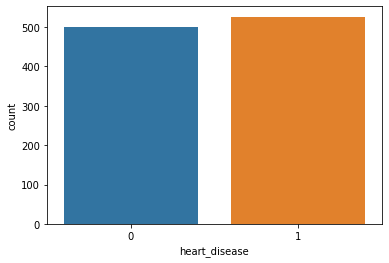

In [16]:
sns.countplot(x="heart_disease", data=df)

In [17]:
# Yes there are 523 heart disease and 495 No heart disease patients.
# overall its a balance dataset .

In [18]:
df["rest_cp"].value_counts()

0    497
2    284
1    167
3     77
Name: rest_cp, dtype: int64

In [19]:
"""
‘rest_cp’……..Chest pain type
………… 0 = Typical angina
………… 1 = Atypical angina
………… 2 = Non-anginal pain
………… 3 = Asymptomatic
"""



'\n‘rest_cp’……..Chest pain type\n………… 0 = Typical angina\n………… 1 = Atypical angina\n………… 2 = Non-anginal pain\n………… 3 = Asymptomatic\n'

In [20]:
df["fast_bloodsugar"].value_counts()

0    872
1    153
Name: fast_bloodsugar, dtype: int64

In [21]:
"""
‘fast_bloodsugar’…….(Fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)
"""

'\n‘fast_bloodsugar’…….(Fasting blood sugar > 120 mg/dl) (1 = true; 0 = false)\n'

In [22]:
#‘rest_bp’..Resting blood pressure (in mm Hg on admission to the hospital)

In [23]:
df["rest_ecg"].value_counts()

1    513
0    497
2     15
Name: rest_ecg, dtype: int64

In [24]:
"""‘rest_ecg’…Resting electrocardiographic results
………… 0 = Normal
………… 1 = Having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)
………… 2= Showing probable or definite left ventricular hypertrophy by Estes’ criteria
"""

'‘rest_ecg’…Resting electrocardiographic results\n………… 0 = Normal\n………… 1 = Having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV)\n………… 2= Showing probable or definite left ventricular hypertrophy by Estes’ criteria\n'

In [25]:
#‘stress_HR’…Maximum heart rate achieved during stress test

In [26]:
df["Exercise_cp"].value_counts()

0    680
1    345
Name: Exercise_cp, dtype: int64

In [27]:
#‘Exercise_cp’…..Exercise induced angina (1 = yes; 0 = no)

In [28]:
#‘STdepression_Exerc’…ST depression induced by exercise relative to rest

In [29]:
df["STpeak_exerc"].value_counts()

1    482
2    469
0     74
Name: STpeak_exerc, dtype: int64

In [30]:
#‘STpeak_exerc’…..Slope of the peak exercise ST segment
#………… 0 = upsloping; 1 = flat; 2 = downsloping

In [31]:
df["coloured_vessels"].value_counts()

0    578
1    226
2    134
3     69
4     18
Name: coloured_vessels, dtype: int64

In [32]:
#‘coloured_vessels’………Number of major vessels (0-3) found colored by flourosopy measurement

In [33]:
df["thalassmia"].value_counts()

2    544
3    410
1     64
0      7
Name: thalassmia, dtype: int64

In [34]:
#‘thalassmia’…….0 = null;1=normal; 2 = fixed defect; 3 = reversable defect



In [35]:
# DELETING THE ROWS WHERE thalassmia==0

df = df[(df['thalassmia'] > 0)]

In [36]:
df["thalassmia"].value_counts()

2    544
3    410
1     64
Name: thalassmia, dtype: int64

In [37]:
df.describe()

,age,gender,rest_cp,rest_bp,cholesterol,fast_bloodsugar,rest_ecg,stress_HR,Exercise_cp,STdepression_Exerc,STpeak_exerc,coloured_vessels,thalassmia,heart_disease
count,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000
mean,54.447937,0.696464,0.943026,131.636542,246.253438,0.146365,0.529470,149.187623,0.334971,1.074951,1.385069,0.759332,2.339882,0.513752
std,9.101835,0.460011,1.029886,17.574327,51.676406,0.353646,0.528086,23.006116,0.472212,1.177640,0.618506,1.032432,0.591982,0.500057
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.750000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


[Text(0.5, 0, 'gender of patients')]

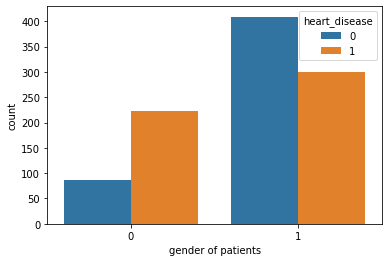

In [38]:
gender_count=sns.countplot(x="gender", data=df,hue="heart_disease")
gender_count.set(xlabel="gender of patients")

In [39]:
# female mostly has less chances of heart disease as compare to male.

In [40]:
# condition (target) : 0 = no disease, 1 = disease
#sex  (0 = female, 1 = male )

In [41]:
"""CP:- chest pain type (4 values) 
    – Value 0: typical angina
    – Value 1: atypical angina
    – Value 2: non-anginal pain 
    – Value 3: asymptomatic"""

"""Typical angina means that the history of the patient is classical and chance of having coronary artery blockages is high. 

Atypical angina means that the symptoms have some features suggesting blockages and other symptoms which are not specific and chance of blockages is lower.

"silent" (asymptomatic) myocardial ischemia is the most common manifestation of coronary heart disease (CHD)"""

'Typical angina means that the history of the patient is classical and chance of having coronary artery blockages is high. \n\nAtypical angina means that the symptoms have some features suggesting blockages and other symptoms which are not specific and chance of blockages is lower.\n\n"silent" (asymptomatic) myocardial ischemia is the most common manifestation of coronary heart disease (CHD)'

<AxesSubplot:xlabel='rest_cp', ylabel='count'>

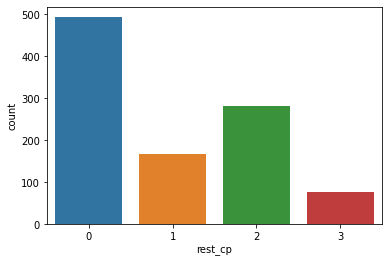

In [42]:
sns.countplot(x="rest_cp", data=df)

[Text(0, 0.5, 'Percent')]

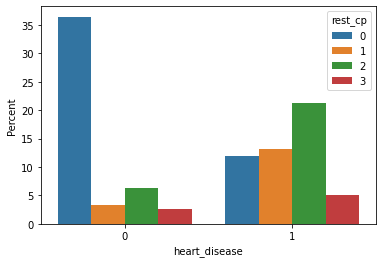

In [43]:
ax = sns.barplot(x="heart_disease", y="rest_cp", data=df,hue="rest_cp", estimator=lambda x: len(x) / len(df) * 100)
ax.set(ylabel="Percent")

In [44]:
df["gender"].value_counts()

1    709
0    309
Name: gender, dtype: int64

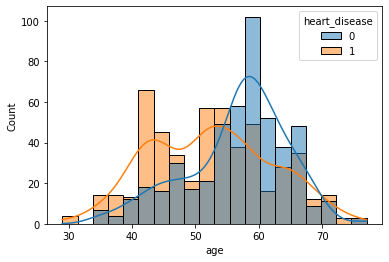

In [45]:
sns.histplot(data=df,x="age",hue="heart_disease",bins=20,kde=True)
plt.show()

In [46]:
# condition (target) : 0 = no disease, 1 = disease
# We can say ; Cardiovascular diseases maximum risk at age 40-65 age

#sex  (0 = female, 1 = male )

In [47]:
# condition (target) : 0 = no disease, 1 = disease
#cp (0 = , 1 = male,2=,3= )

Text(0.5, 1.0, 'thal Type v/s target\n')

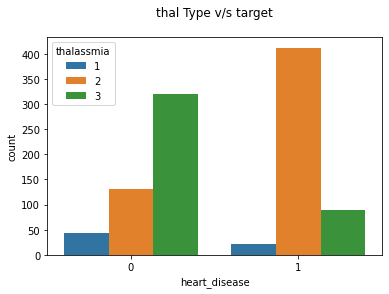

In [48]:
sns.countplot(data= df, x='heart_disease',hue='thalassmia')
plt.title('thal Type v/s target\n')

In [49]:
# condition (target) : 0 = no disease, 1 = disease


Thalassemia (thal-uh-SEE-me-uh) is an inherited blood disorder that causes your body to have less hemoglobin than normal. Hemoglobin enables red blood cells to carry oxygen


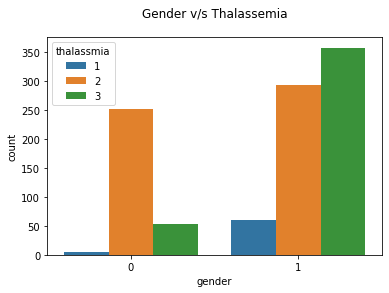

In [50]:
sns.countplot(data= df, x='gender',hue='thalassmia')
plt.title('Gender v/s Thalassemia\n')
print('Thalassemia (thal-uh-SEE-me-uh) is an inherited blood disorder that causes your body to have less hemoglobin than normal. Hemoglobin enables red blood cells to carry oxygen')

In [51]:
"""The Beta thalassemia cardiomyopathy is mainly characterized by two distinct pheno types , dilated type, 
with left ventricular dilatation and impaired contractility and a restrictive pheno type, with restrictive left 
ventricular feeling , pulmonary hyper tension and right heart failure. Heart problems, congestive heart failures and 
abnormal heart rhythms can be associated with severe thalassemia."""

'The Beta thalassemia cardiomyopathy is mainly characterized by two distinct pheno types , dilated type, \nwith left ventricular dilatation and impaired contractility and a restrictive pheno type, with restrictive left \nventricular feeling , pulmonary hyper tension and right heart failure. Heart problems, congestive heart failures and \nabnormal heart rhythms can be associated with severe thalassemia.'

<AxesSubplot:xlabel='heart_disease', ylabel='age'>

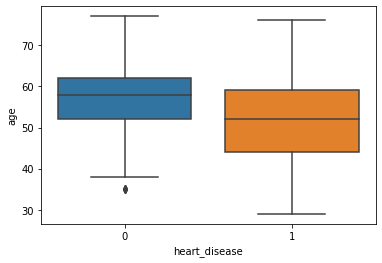

In [52]:
sns.boxplot(data=df,x='heart_disease',y='age')

In [53]:
"""From the positive disease , we can analyze that our 25th Percentile is 44 year i.e  which means 25% of the patient age  is less than 44 year.
50th percentile is 50 year,50% of heart disease patients lies below 50 year.
75th Percentile value is 58 meaning 75% of data lies below 58."""


'From the positive disease , we can analyze that our 25th Percentile is 44 year i.e  which means 25% of the patient age  is less than 44 year.\n50th percentile is 50 year,50% of heart disease patients lies below 50 year.\n75th Percentile value is 58 meaning 75% of data lies below 58.'

In [54]:
# MISSING VALUES AND EDA PART

In [55]:
# CHECKING FOR MISSING VALUES

In [56]:
df.isnull().sum()

age                   0
gender                0
rest_cp               0
rest_bp               0
cholesterol           0
fast_bloodsugar       0
rest_ecg              0
stress_HR             0
Exercise_cp           0
STdepression_Exerc    0
STpeak_exerc          0
coloured_vessels      0
thalassmia            0
heart_disease         0
dtype: int64

In [57]:
"""There is no missing values If there were
null values we needed to drop/eliminate or apply mean, median mode as per requirements to ensure an
higher performance."""

'There is no missing values If there were\nnull values we needed to drop/eliminate or apply mean, median mode as per requirements to ensure an\nhigher performance.'

In [58]:
df.heart_disease.value_counts()


1    523
0    495
Name: heart_disease, dtype: int64

In [59]:
#clearly we have a balance dataset.
# 2* minority class>majority class.
# Although it is a clinical dataset , incase of IMBALANCE situation , it is advisable not to balance it because it is sensitive datas.

In [60]:
df.nunique()

age                    41
gender                  2
rest_cp                 4
rest_bp                49
cholesterol           152
fast_bloodsugar         2
rest_ecg                3
stress_HR              91
Exercise_cp             2
STdepression_Exerc     40
STpeak_exerc            3
coloured_vessels        5
thalassmia              3
heart_disease           2
dtype: int64

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1018 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   age                 1018 non-null   int64  
 1   gender              1018 non-null   int64  
 2   rest_cp             1018 non-null   int64  
 3   rest_bp             1018 non-null   int64  
 4   cholesterol         1018 non-null   int64  
 5   fast_bloodsugar     1018 non-null   int64  
 6   rest_ecg            1018 non-null   int64  
 7   stress_HR           1018 non-null   int64  
 8   Exercise_cp         1018 non-null   int64  
 9   STdepression_Exerc  1018 non-null   float64
 10  STpeak_exerc        1018 non-null   int64  
 11  coloured_vessels    1018 non-null   int64  
 12  thalassmia          1018 non-null   int64  
 13  heart_disease       1018 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 151.6 KB


In [62]:
#All datas are in Int or Float type typecasting not required.


# NEXT STEP TO DO THE PREPROCESSING EDA PART 

# OUTLIER TRETMENT  

In [63]:
# ALTHOUGH ITS A CLASSIFICATION PROBLEM OUTLIER TREATMENT IS NOT REQUIRED IN CLASSIFICATION.
# OUTLIER  PLAY HIGH IMPACT IN REGRESSION PROBLEM .#It is not good idea to remove the data by outlier treatment ,
#its better to do square root , or log transformation in place of removing outliers.
# instead of doing outlier and then doing feature scalling , the good idea is to feature scalling directly.
#because after feature scalling many outliers aumatically come in to the range.

# since we are using random forest Bagging method feature scalling is also not required.(no standardization impact)

In [64]:
#Splitting the data into independent variable and dependent variable
# the target variable is heart_ disease

In [65]:
X=df.drop(["heart_disease"],axis=1)
Y=df["heart_disease"]

In [66]:
#Feature scaling is one of the most important data preprocessing step in machine learning. 
#Algorithms that compute the distance between the features are biased towards numerically larger values 
#if the data is not scaled.
#Tree-based algorithms are fairly insensitive to the scale of the features.
# Normalization is useful when there are no outliers as it cannot cope up with them. otherwise its better to opt standarization.

In [67]:
X.describe()

,age,gender,rest_cp,rest_bp,cholesterol,fast_bloodsugar,rest_ecg,stress_HR,Exercise_cp,STdepression_Exerc,STpeak_exerc,coloured_vessels,thalassmia
count,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000,1018.000000
mean,54.447937,0.696464,0.943026,131.636542,246.253438,0.146365,0.529470,149.187623,0.334971,1.074951,1.385069,0.759332,2.339882
std,9.101835,0.460011,1.029886,17.574327,51.676406,0.353646,0.528086,23.006116,0.472212,1.177640,0.618506,1.032432,0.591982
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,48.000000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000
50%,56.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000
75%,61.000000,1.000000,2.000000,140.000000,275.750000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000


In [68]:
# Feature scaling standarization to bring all the values 0 and -3.

In [69]:
from sklearn.preprocessing import StandardScaler
scaljob=StandardScaler()
X_scaled=scaljob.fit_transform(X)
X_scaled



array([[-0.26908204,  0.66017051, -0.91611061, ...,  0.99470897,
         1.20228531,  1.11564509],
       [-0.15916008,  0.66017051, -0.91611061, ..., -2.24047867,
        -0.73584049,  1.11564509],
       [ 1.70951317,  0.66017051, -0.91611061, ..., -2.24047867,
        -0.73584049,  1.11564509],
       ...,
       [-0.81869182,  0.66017051, -0.91611061, ..., -0.62288485,
         0.23322241, -0.57442441],
       [-0.48892595, -1.51476017, -0.91611061, ...,  0.99470897,
        -0.73584049, -0.57442441],
       [-0.04923813,  0.66017051, -0.91611061, ..., -0.62288485,
         0.23322241,  1.11564509]])

In [70]:
# we are getting the array value we sould change it in DATAFRAME 
X_scaled_DF=pd.DataFrame(X_scaled,index=X.index,columns=X.columns)
# HERE WE ARE USING THE INDEX  and COLUMN NAME OF Newdata
X_scaled_DF

,age,gender,rest_cp,rest_bp,cholesterol,fast_bloodsugar,rest_ecg,stress_HR,Exercise_cp,STdepression_Exerc,STpeak_exerc,coloured_vessels,thalassmia
0,-0.269082,0.660171,-0.916111,-0.377813,-0.663171,-0.414079,0.891449,0.818114,-0.709713,-0.063676,0.994709,1.202285,1.115645
1,-0.159160,0.660171,-0.916111,0.476125,-0.837417,2.414998,-1.003112,0.252769,1.409020,1.720428,-2.240479,-0.735840,1.115645
2,1.709513,0.660171,-0.916111,0.760770,-1.398877,-0.414079,0.891449,-1.051873,1.409020,1.295641,-2.240479,-0.735840,1.115645
3,0.720216,0.660171,-0.916111,0.931558,-0.837417,-0.414079,0.891449,0.513697,-0.709713,-0.913250,0.994709,0.233222,1.115645
4,0.830138,-1.514760,-0.916111,0.362266,0.924407,2.414998,0.891449,-1.878146,-0.709713,0.700940,-0.622885,2.171348,-0.574424
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,0.500372,0.660171,0.055348,0.476125,-0.488924,-0.414079,0.891449,0.644162,1.409020,-0.913250,0.994709,-0.735840,-0.574424
1021,0.610294,0.660171,-0.916111,-0.377813,0.227422,-0.414079,-1.003112,-0.356064,1.409020,1.465556,-0.622885,0.233222,1.115645
1022,-0.818692,0.660171,-0.916111,-1.231750,0.556554,-0.414079,-1.003112,-1.356289,1.409020,-0.063676,-0.622885,0.233222,-0.574424
1023,-0.488926,-1.514760,-0.916111,-1.231750,0.149979,-0.414079,-1.003112,0.426721,-0.709713,-0.913250,0.994709,-0.735840,-0.574424


# multicollinearity problems

In [71]:
#Actually, we are interested in classification, No need to get rid of collinear variables. 
#Multicollinearity mostly occurs in a regression model when two or more independent variable are highly correlated to eachother.



In [72]:
#X_scaled.corr() # it fetch error due to not being dataframe shape

In [73]:
X_scaled_DF.corr()

,age,gender,rest_cp,rest_bp,cholesterol,fast_bloodsugar,rest_ecg,stress_HR,Exercise_cp,STdepression_Exerc,STpeak_exerc,coloured_vessels,thalassmia
age,1.000000,-0.103705,-0.072695,0.270896,0.219127,0.125020,-0.132652,-0.392010,0.089739,0.207939,-0.169703,0.270985,0.070079
gender,-0.103705,1.000000,-0.034464,-0.079704,-0.199939,0.019504,-0.062310,-0.057143,0.133562,0.081243,-0.020783,0.111042,0.202289
rest_cp,-0.072695,-0.034464,1.000000,0.038187,-0.083220,0.090412,0.050097,0.314440,-0.397442,-0.172972,0.127094,-0.177516,-0.174645
rest_bp,0.270896,-0.079704,0.038187,1.000000,0.127212,0.185604,-0.124076,-0.040066,0.062197,0.187088,-0.120631,0.103722,0.056779
cholesterol,0.219127,-0.199939,-0.083220,0.127212,1.000000,0.034286,-0.146994,-0.023484,0.071103,0.063311,-0.014593,0.070920,0.086248
fast_bloodsugar,0.125020,0.019504,0.090412,0.185604,0.034286,1.000000,-0.115258,-0.013651,0.035855,0.010465,-0.055631,0.145048,-0.012411
rest_ecg,-0.132652,-0.062310,0.050097,-0.124076,-0.146994,-0.115258,1.000000,0.043289,-0.073141,-0.052807,0.091662,-0.078055,-0.019490
stress_HR,-0.392010,-0.057143,0.314440,-0.040066,-0.023484,-0.013651,0.043289,1.000000,-0.388107,-0.355342,0.402621,-0.211336,-0.116161
Exercise_cp,0.089739,0.133562,-0.397442,0.062197,0.071103,0.035855,-0.073141,-0.388107,1.000000,0.311099,-0.263637,0.111065,0.221954
STdepression_Exerc,0.207939,0.081243,-0.172972,0.187088,0.063311,0.010465,-0.052807,-0.355342,0.311099,1.000000,-0.574654,0.220350,0.201930


<AxesSubplot:>

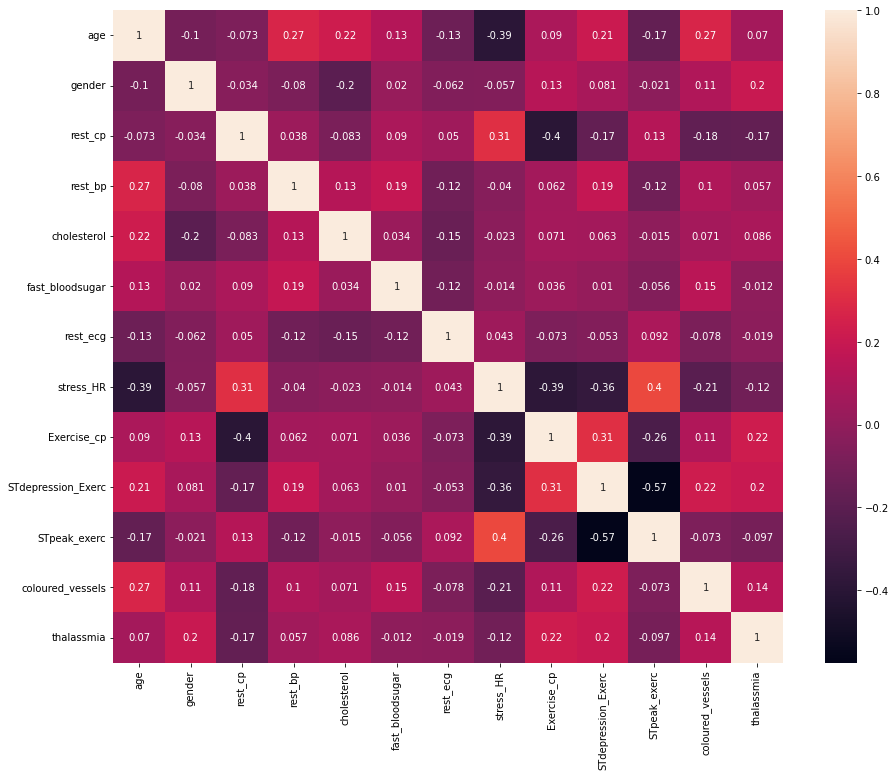

In [74]:
# Although in classification problem , there is no impact of multi-collinearity in case of classificataion problem if there are any two values are same , it is called Multi collinearity. than we can drop any of that equal Ind Variable.
#Same data we can plot in heatmap for more better understanding.
plt.figure(figsize=(15,12))
sns.heatmap(X_scaled_DF.corr(),annot=True)

In [75]:
# although there is no Multicolliniearilty ,if a value more than 0.8 ( specific to Medical and clinical sector data it consider as multicollinearity).

In [76]:
#SPLITTING THE DATA IN TRAINING AND TEST

from sklearn.model_selection import train_test_split


In [77]:
print(X.shape)
print(Y.shape)

(1018, 13)
(1018,)


In [78]:
#unscaled datas
X_train, X_test,Y_train,Y_test=train_test_split(X,Y,train_size=0.70,random_state=101)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(712, 13)
(306, 13)
(712,)
(306,)


In [79]:
X_test

,age,gender,rest_cp,rest_bp,cholesterol,fast_bloodsugar,rest_ecg,stress_HR,Exercise_cp,STdepression_Exerc,STpeak_exerc,coloured_vessels,thalassmia
909,50,1,0,144,200,0,0,126,1,0.9,1,0,3
241,67,1,2,152,212,0,0,150,0,0.8,1,0,3
433,37,1,2,130,250,0,1,187,0,3.5,0,0,2
952,54,0,2,135,304,1,1,170,0,0.0,2,0,2
148,52,1,3,152,298,1,1,178,0,1.2,1,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,42,1,0,140,226,0,1,178,0,0.0,2,0,2
403,46,0,1,105,204,0,1,172,0,0.0,2,0,2
843,59,1,3,160,273,0,0,125,0,0.0,2,0,2
334,60,1,0,130,206,0,0,132,1,2.4,1,2,3


In [80]:
#scaled datas
X_train1, X_test1,Y_train,Y_test=train_test_split(X_scaled_DF,Y,train_size=0.70,random_state=101)
print(X_train1.shape)
print(X_test1.shape)
print(Y_train.shape)
print(Y_test.shape)

(712, 13)
(306, 13)
(712,)
(306,)


# LOGISTIC REGRESSION

In [81]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train1,Y_train)

LogisticRegression()

In [82]:
Y_pred_lr_train=lr.predict(X_train1)

Y_pred_lr_test=lr.predict(X_test1)

In [83]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
print("LOGISTIC REGRESSION TRAINING ACCURACY ",accuracy_score(Y_train,Y_pred_lr_train))
print("######"*20)
print("LOGISTIC REGRESSION TESTING ACCURACY ",accuracy_score(Y_test,Y_pred_lr_test))

LOGISTIC REGRESSION TRAINING ACCURACY  0.8623595505617978
########################################################################################################################
LOGISTIC REGRESSION TESTING ACCURACY  0.8398692810457516


In [84]:
# confusion matrix
"""Confusion matrix got its name from the fact that it easier to 
identify if the classification model is getting 
confused or not. For a classification model, confusion can result 
in misidentifying the data, which further results in 
performance degradation."""

"""When a Machine Learning model is built various evaluation metrics 
are used to check the quality or the performance of a
model. For classification models, metrics such as Accuracy, 
Confusion Matrix, Classification report (i.e Precision, Recall, F1
score), and AUC-ROC curve are used"""



'When a Machine Learning model is built various evaluation metrics \nare used to check the quality or the performance of a\nmodel. For classification models, metrics such as Accuracy, \nConfusion Matrix, Classification report (i.e Precision, Recall, F1\nscore), and AUC-ROC curve are used'

# CONFUSION METRIX

[[122  26]
 [ 23 135]]


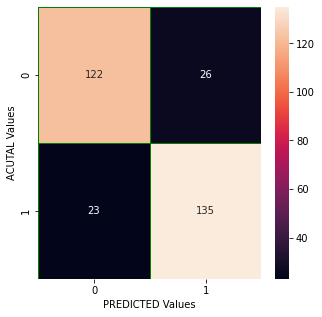

In [85]:
lr_conf_mat=confusion_matrix(Y_test,Y_pred_lr_test)
print(confusion_matrix(Y_test,Y_pred_lr_test))

#Visualization Confusion Matrix
plt.subplots(figsize=(5,5))
sns.heatmap(lr_conf_mat,annot=True,linewidths=0.5,linecolor="green",fmt=".0f")

plt.xlabel("PREDICTED Values")
plt.ylabel("ACUTAL Values")
plt.show()

In [86]:
TN, FP, FN, TP = lr_conf_mat.ravel()

print('True Negative(TN)  = ', TN)
print('False Positive(FP) = ', FP)
print('True Positive(TP)  = ', TP)
print('False Negative(FN) = ', FN)

True Negative(TN)  =  122
False Positive(FP) =  26
True Positive(TP)  =  135
False Negative(FN) =  23


In [87]:
print("## CLASSIFICATION REPORT DT TRAINING MODEL ######")
print(classification_report(Y_train,Y_pred_lr_train))
print("## CLASSIFICATION REPORT DT TESTING MODEL  ######")
print(classification_report(Y_test,Y_pred_lr_test))

## CLASSIFICATION REPORT DT TRAINING MODEL ######
              precision    recall  f1-score   support

           0       0.88      0.83      0.85       347
           1       0.85      0.89      0.87       365

    accuracy                           0.86       712
   macro avg       0.86      0.86      0.86       712
weighted avg       0.86      0.86      0.86       712

## CLASSIFICATION REPORT DT TESTING MODEL  ######
              precision    recall  f1-score   support

           0       0.84      0.82      0.83       148
           1       0.84      0.85      0.85       158

    accuracy                           0.84       306
   macro avg       0.84      0.84      0.84       306
weighted avg       0.84      0.84      0.84       306



In [88]:
"""## condition (target) : 0 = no disease, 1 = disease

#PRECISION REPORT

Precision is the fraction of true positive examples
among the examples that the model classified as
positive. In other words, the number of true positives
divided by the number of false positives plus true
positives.

# In training Model The classification report of the model shows that 89% prediction of absence of heart disease was predicted correct 
#and 99 % of presence of heart disease was predicted correct.

#In testing Model The classification report of the model shows that 89% prediction of absence of heart disease was predicted correct 
#and 92 % of presence of heart disease was predicted correct.

# RECALL
Recall, also known as sensitivity, is the fraction of
examples classified as positive, among the total
number of positive examples. In other words, the
number of true positives divided by the number of true
positives plus false negatives.

# F SCORE

The F-score, also called the F1-score, is a measure of a model’s accuracy
on a dataset. It is used to evaluate binary classification systems, which
classify examples into ‘positive’ or ‘negative’.
The formula for the standard F1-score is the harmonic mean of the
precision and recall

 We consider a convolutional neural network in
the medical domain, which evaluates mammograms and detects
tumors. We consider it much worse to miss a tumor than to give a false
alarm to a nonexistent tumor.

# SUPPORT no. of examples as 0 and 1.

#macro-avg is mean average of precision/recall/F1 of all classes. 
 while weighed avg is the total number TP (true positive of all classes)/total number of objects in all classes. """
 

'## condition (target) : 0 = no disease, 1 = disease\n\n#PRECISION REPORT\n\nPrecision is the fraction of true positive examples\namong the examples that the model classified as\npositive. In other words, the number of true positives\ndivided by the number of false positives plus true\npositives.\n\n# In training Model The classification report of the model shows that 89% prediction of absence of heart disease was predicted correct \n#and 99 % of presence of heart disease was predicted correct.\n\n#In testing Model The classification report of the model shows that 89% prediction of absence of heart disease was predicted correct \n#and 92 % of presence of heart disease was predicted correct.\n\n# RECALL\nRecall, also known as sensitivity, is the fraction of\nexamples classified as positive, among the total\nnumber of positive examples. In other words, the\nnumber of true positives divided by the number of true\npositives plus false negatives.\n\n# F SCORE\n\nThe F-score, also called the

In [89]:
#ROC is a probability curve and AUC represents the degree or measure of separability.
"""The classification done internally on the based on thershold value... 
similar to DEEP Leaning different activation function.
Assuming a threshold of 0.5 for a model classifier, than the 
value 0.6,0.7,0.8,0.9 consider as 1. it is misleading.
Assuming a threshold of 0.78 for a model classifier, 
than the value 0.6,0.7 will not consider as  consider as 1."""

"""
TPR (True Positive Rate)
FPR (False Positive Rate)

TPR (True Positive Rate)/Sensitivity/Recall = TP/(TP+FN)

The FPR is the proportion of innocents we incorrectly predicted as 
criminal (false positives) 
divided by the total number of actual innocent citizens. Thus, 
the numerator is innocents captured, and the denominator is 
total innocents.

FPR (False Positive Rate) = FP/(TN+FP)

Usually, we want high TPR  and low FPR 

The balanced accuracy, often used when the two classes are imbalanced – 
that is, one class appears 
much more than the other class.



Balanced ACCURACY=(Recall +Specificity)/2.

Specificity =TNR =TN/(TN+FP)

SENSITIVITY=Recall = TP/(TP+FN)

Balanced ACCURACY=(Recall +Specificity)/2.

"""


'\nTPR (True Positive Rate)\nFPR (False Positive Rate)\n\nTPR (True Positive Rate)/Sensitivity/Recall = TP/(TP+FN)\n\nThe FPR is the proportion of innocents we incorrectly predicted as \ncriminal (false positives) \ndivided by the total number of actual innocent citizens. Thus, \nthe numerator is innocents captured, and the denominator is \ntotal innocents.\n\nFPR (False Positive Rate) = FP/(TN+FP)\n\nUsually, we want high TPR  and low FPR \n\nThe balanced accuracy, often used when the two classes are imbalanced – \nthat is, one class appears \nmuch more than the other class.\n\n\n\nBalanced ACCURACY=(Recall +Specificity)/2.\n\nSpecificity =TNR =TN/(TN+FP)\n\nSENSITIVITY=Recall = TP/(TP+FN)\n\nBalanced ACCURACY=(Recall +Specificity)/2.\n\n'

In [90]:
Specificity=TN/(TN+FP)
Recall = TP/(TP+FN)
Balanced_ACCURACY=(Recall +Specificity)/2
print("Specificity of the model  :",Specificity)
print("Recall of the Model  :",Recall)
print("Balanced Accuracy",Balanced_ACCURACY)

Specificity of the model  : 0.8243243243243243
Recall of the Model  : 0.8544303797468354
Balanced Accuracy 0.8393773520355798


In [91]:
#ROC is a probability curve and AUC represents the degree or measure of separability.
"""The classification done internally on the based on thershold value... 
similar to DEEP Leaning different activation function.
Assuming a threshold of 0.5 for a model classifier, than the value 0.6,0.7,0.8,0.9 
consider as 1. it is misleading.
Assuming a threshold of 0.78 for a model classifier, than the value 0.6,0.7 will not 
consider as  consider as 1."""

"""
TPR (True Positive Rate)
FPR (False Positive Rate)

To explain TPR and FPR, Lets take the example of justice system. 
Naturally, any justice system only wants to punish people 
guilty of crimes and doesn’t want to charge an innocent person. 

consider 0 for (innocent) or a 1 for (guilty).

In this case, the TPR is the proportion of guilty criminals our model was able to capture. 
Thus, the numerator is guilty criminals captured, and the denominator is total criminals. 
This ratio is also known as recall or sensitivity.

TPR (True Positive Rate)/Sensitivity/Recall = TP/(TP+FN)

The FPR is the proportion of innocents we incorrectly 
predicted as criminal (false positives) 
divided by the total number of actual innocent citizens. 
Thus, the numerator is innocents captured, and the denominator is 
total innocents.

FPR (False Positive Rate) = FP/(TN+FP)

Usually, we would want high TPR or RECALL (because we want to capture all the criminals) 
and low FPR (because we don’t want to capture innocent people).
"""


'\nTPR (True Positive Rate)\nFPR (False Positive Rate)\n\nTo explain TPR and FPR, Lets take the example of justice system. \nNaturally, any justice system only wants to punish people \nguilty of crimes and doesn’t want to charge an innocent person. \n\nconsider 0 for (innocent) or a 1 for (guilty).\n\nIn this case, the TPR is the proportion of guilty criminals our model was able to capture. \nThus, the numerator is guilty criminals captured, and the denominator is total criminals. \nThis ratio is also known as recall or sensitivity.\n\nTPR (True Positive Rate)/Sensitivity/Recall = TP/(TP+FN)\n\nThe FPR is the proportion of innocents we incorrectly \npredicted as criminal (false positives) \ndivided by the total number of actual innocent citizens. \nThus, the numerator is innocents captured, and the denominator is \ntotal innocents.\n\nFPR (False Positive Rate) = FP/(TN+FP)\n\nUsually, we would want high TPR or RECALL (because we want to capture all the criminals) \nand low FPR (because

In [92]:

"""
“Area Under the ROC Curve” (AUC) of “Receiver Characteristic Operator” (ROC). 

The higher the AUC, the better the performance of the model at 
distinguishing between the positive and negative classes.
When AUC = 1, then the classifier is able to perfectly distinguish between 
all the Positive and the 
Negative class points correctly. If, however, the AUC had been 0, 
then the classifier would be predicting all Negatives
as Positives, and all Positives as Negatives.

When AUC=0.5, then the classifier is not able to distinguish 
between Positive and Negative class points. 
Meaning either the classifier is predicting random 
class or constant class for all the data points.
So, the higher the AUC value for a classifier, the better its 
ability to distinguish between positive and negative classes."""


'\n“Area Under the ROC Curve” (AUC) of “Receiver Characteristic Operator” (ROC). \n\nThe higher the AUC, the better the performance of the model at \ndistinguishing between the positive and negative classes.\nWhen AUC = 1, then the classifier is able to perfectly distinguish between \nall the Positive and the \nNegative class points correctly. If, however, the AUC had been 0, \nthen the classifier would be predicting all Negatives\nas Positives, and all Positives as Negatives.\n\nWhen AUC=0.5, then the classifier is not able to distinguish \nbetween Positive and Negative class points. \nMeaning either the classifier is predicting random \nclass or constant class for all the data points.\nSo, the higher the AUC value for a classifier, the better its \nability to distinguish between positive and negative classes.'

In [93]:
"""Based on sklearn documentation, predict_proba returns probability 
estimates for all classes and the results are ordered by 
the label of classes.
our lr model is a binary classifier. Hence, lr.predict_proba(X_test1) 
returns 2 columns for the negative(0) and positive class(1)."""

probability1 = lr.predict_proba(X_test1)


print(probability1)

[[9.46816808e-01 5.31831917e-02]
 [6.18638234e-01 3.81361766e-01]
 [4.71262402e-01 5.28737598e-01]
 [9.98736512e-03 9.90012635e-01]
 [3.51229706e-01 6.48770294e-01]
 [9.98193380e-01 1.80662012e-03]
 [2.06602355e-01 7.93397645e-01]
 [9.77931278e-01 2.20687219e-02]
 [6.18176468e-02 9.38182353e-01]
 [1.38651310e-02 9.86134869e-01]
 [8.94345938e-01 1.05654062e-01]
 [2.06602355e-01 7.93397645e-01]
 [9.73379381e-01 2.66206186e-02]
 [1.37123689e-02 9.86287631e-01]
 [7.62387647e-01 2.37612353e-01]
 [1.54837603e-01 8.45162397e-01]
 [1.41933251e-01 8.58066749e-01]
 [9.51894078e-01 4.81059219e-02]
 [9.96249645e-01 3.75035453e-03]
 [9.96249645e-01 3.75035453e-03]
 [5.54976743e-01 4.45023257e-01]
 [9.49596192e-01 5.04038082e-02]
 [5.26318437e-01 4.73681563e-01]
 [2.45933237e-01 7.54066763e-01]
 [2.67826058e-01 7.32173942e-01]
 [3.52919691e-02 9.64708031e-01]
 [3.09502944e-01 6.90497056e-01]
 [3.02303816e-01 6.97696184e-01]
 [1.30694776e-01 8.69305224e-01]
 [4.61102567e-01 5.38897433e-01]
 [1.245717

In [94]:
"""Running lr.predict_proba(X_test)[:,1] get the predicted probabilities 
of the positive label only, which yield as below:-
"""
prob_pos_class= lr.predict_proba(X_test1)[:,1]
prob_pos_class

array([5.31831917e-02, 3.81361766e-01, 5.28737598e-01, 9.90012635e-01,
       6.48770294e-01, 1.80662012e-03, 7.93397645e-01, 2.20687219e-02,
       9.38182353e-01, 9.86134869e-01, 1.05654062e-01, 7.93397645e-01,
       2.66206186e-02, 9.86287631e-01, 2.37612353e-01, 8.45162397e-01,
       8.58066749e-01, 4.81059219e-02, 3.75035453e-03, 3.75035453e-03,
       4.45023257e-01, 5.04038082e-02, 4.73681563e-01, 7.54066763e-01,
       7.32173942e-01, 9.64708031e-01, 6.90497056e-01, 6.97696184e-01,
       8.69305224e-01, 5.38897433e-01, 8.75428237e-01, 3.14196105e-02,
       8.13715741e-01, 3.28313314e-03, 9.21224026e-01, 1.43645418e-01,
       9.45511850e-01, 1.05654062e-01, 9.31441295e-01, 1.17939311e-02,
       3.74819796e-03, 1.00923566e-01, 5.51563533e-01, 8.77025665e-01,
       9.79544868e-01, 9.29514899e-01, 4.59591795e-02, 5.18383537e-01,
       3.61414176e-01, 5.91221488e-01, 1.31370154e-01, 8.11280587e-01,
       8.22184469e-03, 2.35256698e-01, 6.90497056e-01, 9.71586889e-01,
      

In [95]:
from sklearn.metrics import roc_auc_score

# auc scores
auc_score1 = roc_auc_score(Y_test, prob_pos_class)

print("AUC SCORE:",auc_score1)




"""
roc curve for tpr = fpr 
random_probs = [0 for i in range(len(Y_test))]
p_fpr, p_tpr, _ = roc_curve(Y_test, random_probs, pos_label=1)
"""
from sklearn.metrics import roc_curve

# roc curve for models
fpr1, tpr1, thresh1 = roc_curve(Y_test, prob_pos_class, pos_label=1)



print("#######"*5)
print("value of FPR", fpr1)
print("#######"*5)
print("Values of TPR",tpr1)
print("#######"*5)
print("values of Threshold", thresh1)

AUC SCORE: 0.9000171057133082
###################################
value of FPR [0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.02027027
 0.02027027 0.02027027 0.02027027 0.02027027 0.02027027 0.02027027
 0.02027027 0.03378378 0.03378378 0.03378378 0.0472973  0.0472973
 0.0472973  0.0472973  0.0472973  0.0472973  0.0472973  0.06081081
 0.06081081 0.06081081 0.06081081 0.06081081 0.06081081 0.07432432
 0.07432432 0.07432432 0.09459459 0.09459459 0.10135135 0.10135135
 0.10135135 0.10135135 0.10810811 0.10810811 0.11486486 0.11486486
 0.11486486 0.12837838 0.12837838 0.12837838 0.13513514 0.13513514
 0.13513514 0.13513514 0.14189189 0.14189189 0.14864865 0.14864865
 0.15540541 0.15540541 0.16891892 0.16891892 0.16891892 0.18243243
 0.18243243 0.19594595 0.2027027  0.2027027  0.2027027  0.21621622
 0.21621622 0.22297297 0.22297297 0.23648649 0.23648649 0.25
 0.256

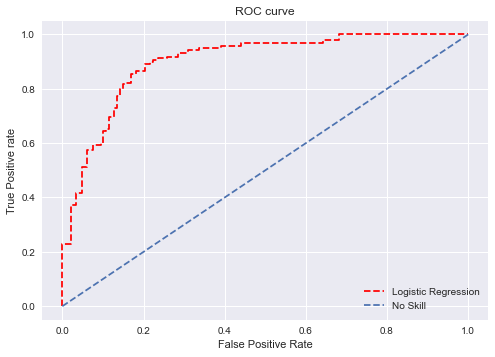

In [96]:
# matplotlib
import matplotlib.pyplot as plt
plt.style.use('seaborn')

# plot roc curves
plt.plot(fpr1, tpr1, linestyle='--',color='red', label='Logistic Regression')

# plot no skill roc curve
plt.plot([0, 1], [0, 1], linestyle='--', label='No Skill')

# title
plt.title('ROC curve')

# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.legend(loc='best')

plt.savefig('ROC', dpi=300)
plt.show()

# KNN

In [97]:
#X_train1, X_test1,Y_train,Y_test

In [98]:
 """The k-nearest neighbours algorithm is one of the transperent 
machine learning algorithms. It is simply based on the idea that 
“objects that are ‘near’ each other will also have similar 
characteristics. Thus if you know the characteristic features of 
one of the objects, you can also predict it for its nearest 
neighbour
 
 It’s used in many different areas, such as Medical, clinical,handwriting detection, image recognition, and video recognition. 
    KNN is most useful when labeled data is too expensive or impossible to obtain.
   KNN algorithm is one of the simplest forms and is widely used in classification tasks in research because of
   easy-to-understand design 

"""


'The k-nearest neighbours algorithm is one of the transperent \nmachine learning algorithms. It is simply based on the idea that \n“objects that are ‘near’ each other will also have similar \ncharacteristics. Thus if you know the characteristic features of \none of the objects, you can also predict it for its nearest \nneighbour\n\nIt’s used in many different areas, such as Medical, clinical,handwriting detection, image recognition, and video recognition. \n   KNN is most useful when labeled data is too expensive or impossible to obtain.\n  KNN algorithm is one of the simplest forms and is widely used in classification tasks in research because of\n  easy-to-understand design \n\n'

In [99]:
from sklearn .metrics import classification_report,confusion_matrix,accuracy_score

In [101]:
from sklearn.neighbors import KNeighborsClassifier
knn_S_5=KNeighborsClassifier(n_neighbors=5) 
knn_S_5.fit(X_train1,Y_train)


Y_pred_KNN_train1=knn_S_5.predict(X_train1)
Y_pred_KNN_test1=knn_S_5.predict(X_test1)

In [103]:
print("KNN training accuracy", accuracy_score(Y_train,Y_pred_KNN_train1))
print("######"*5)
print("KNN testing accuracy", accuracy_score(Y_test,Y_pred_KNN_test1))

KNN training accuracy 0.9508426966292135
##############################
KNN testing accuracy 0.8660130718954249


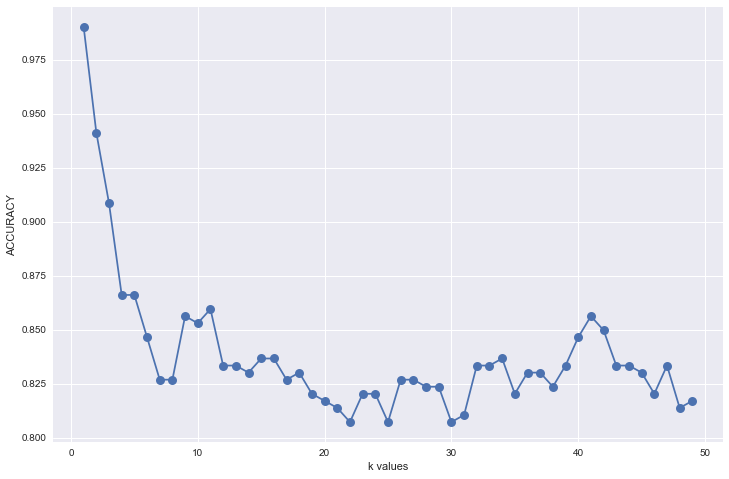

In [106]:
# find the more effective value of n_neighbors parameter:
accuracy_K = []
for k in range(1, 50):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train1, Y_train)
    Y_pred = knn.predict(X_test1)
    accuracy =accuracy_score(Y_test, Y_pred)
    accuracy_K.append(accuracy)
   
plt.figure(figsize=(12,8))
plt.xlabel("k values")
plt.ylabel("ACCURACY")
plt.plot(range(1,50),accuracy_K, marker='o', markersize=9)

In [113]:
# we can try different k values 11
knn_S_25=KNeighborsClassifier(n_neighbors=11) 
knn_S_25.fit(X_train1,Y_train)


Y_pred_KNN_train1=knn_S_25.predict(X_train1)
Y_pred_KNN_test1=knn_S_25.predict(X_test1)

In [114]:
print("KNN training accuracy", accuracy_score(Y_train,Y_pred_KNN_train1))
print("######"*5)
print("KNN testing accuracy", accuracy_score(Y_test,Y_pred_KNN_test1))

KNN training accuracy 0.8848314606741573
##############################
KNN testing accuracy 0.8594771241830066


In [ ]:
ANOTHER APPROACH TO FIND THE BEST K VALUE 

In [109]:
test_error_rate = []
for i in range(1,40):
    knn = KNeighborsClassifier(n_neighbors=i,algorithm='brute', weights='distance')
    knn.fit(X_train1,Y_train)
    pred_test_i = knn.predict(X_test1)
    test_error_rate.append(np.mean(pred_test_i != Y_test))

Text(0, 0.5, 'Error Rate')

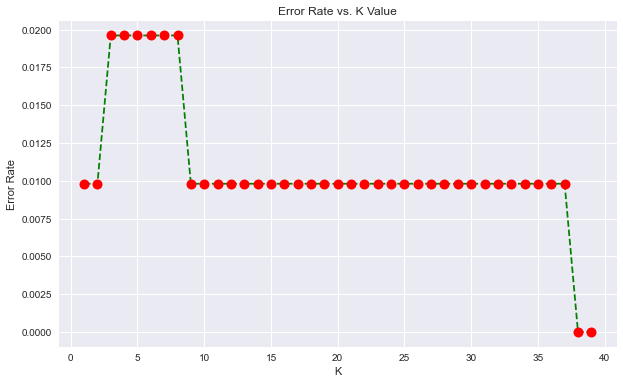

In [110]:
plt.figure(figsize=(10,6))
plt.plot(range(1,40),test_error_rate,color='green', linestyle='dashed', marker='o',markerfacecolor='red', markersize=10)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')

In [111]:
# we can try different k values 39
knn_S_25=KNeighborsClassifier(n_neighbors=39) 
knn_S_25.fit(X_train1,Y_train)


Y_pred_KNN_train1=knn_S_25.predict(X_train1)
Y_pred_KNN_test1=knn_S_25.predict(X_test1)

In [112]:
print("KNN training accuracy", accuracy_score(Y_train,Y_pred_KNN_train1))
print("######"*5)
print("KNN testing accuracy", accuracy_score(Y_test,Y_pred_KNN_test1))

KNN training accuracy 0.8651685393258427
##############################
KNN testing accuracy 0.8333333333333334
